In [1]:
!pip install segmentation-models-pytorch medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.nn.functional import silu, interpolate, relu
from torch.autograd.functional import jvp
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

from medmnist import PneumoniaMNIST

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

---
Decide mode:

In [4]:
MODE = "spatial"   # "spatial"  # "flat"

FLAT_LATENT_DIM = 98
SPATIAL_LATENT_SHAPE = (4,28,28)
GENERATE_LATENTS_WITH_AUTOENCODER = True

---
MFM flat class definitions

In [ ]:
# @title
class RBFMetric(nn.Module):
    def __init__(self,
                 n_clusters = 50,
                 kappa = 4.0,
                 alpha=1.0,
                 rho=1e-2,
                 eps=1e-8,
                 w_min=1e-4):
        super().__init__()
        self.n_clusters = int(n_clusters)
        self.kappa = float(kappa)
        self.alpha = float(alpha)
        self.rho = float(rho)
        self.eps = float(eps)
        self.w_min = float(w_min)

        self.kmeans = KMeans(n_clusters=self.n_clusters)

        self.W = nn.Parameter(self.w_min + 1e-3 * torch.rand(self.n_clusters, dtype=torch.float32))

        # set after train_kmeans
        self.cluster_centers = None   # (K, D) torch
        self.lambdas = None           # (K,) torch

    @torch.no_grad()
    def train_kmeans(self, data: np.array, device=None):
        print(f"Fitting kmeans")
        self.kmeans.fit(data)
        print(f"Computing auxiliary variables")

        centers = self.kmeans.cluster_centers_          # (K, D)
        labels = self.kmeans.labels_                    # (N,)

        # sigma_k from per-cluster variance
        sigmas = np.zeros((self.n_clusters,), dtype=np.float32)
        for k in range(self.n_clusters):
            pts = data[labels == k]                     # (n_k, D)
            # variance per dim, then average across dims (robust scalar bandwidth)
            var = ((pts - centers[k]) ** 2).mean(axis=0)  # (D,)
            sigmas[k] = np.sqrt(var.mean() + 1e-12)

        sigma_floor = 3e-2 #1e-2  # start here; tune if needed
        sigmas = np.maximum(sigmas, sigma_floor)
        # lambda_k = 0.5 / (kappa * sigma_k)^2
        lambdas = 0.5 / ((self.kappa * sigmas) ** 2 + 1e-12)

        dev = device if device is not None else next(self.parameters()).device
        self.cluster_centers = torch.tensor(centers, dtype=torch.float32, device=dev)
        self.lambdas = torch.tensor(lambdas, dtype=torch.float32, device=dev)

        print(f"done")

    @torch.no_grad()
    def clampW(self):
        # keep W positive
        self.W.data.clamp_(min=self.w_min)

    def forward(self, x: torch.Tensor):
        if self.cluster_centers is None or self.lambdas is None:
            raise RuntimeError("Call train_kmeans(...) before using the metric.")

        x = x.to(dtype=torch.float32)
        C = self.cluster_centers
        lam = self.lambdas  # (K,)

        # squared distances (B, K)
        dist2 = torch.cdist(x, C, p=2) ** 2

        # phi (B, K)
        phi = torch.exp(-0.5 * dist2 * lam.unsqueeze(0))

        # positive weights (no normalization)
        W_pos = torch.clamp(self.W, min=self.w_min)     # (K,)
        h = (phi * W_pos.unsqueeze(0)).sum(dim=1)       # (B,)

        return h

    def compute_metric(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns metric factor M(x) used in the MFM norm (higher away from data).
        M(x) = 1 / (h(x) + rho)^alpha
        """
        h = self.forward(x)
        M = 1.0 / (h + self.rho) ** self.alpha
        return M

In [ ]:
# @title
class Gamma(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()

        self.timestep_embed = nn.Linear(1,2*latent_dim)
        self.mlp = nn.ModuleList([
                                nn.Linear(2*latent_dim, 2*latent_dim),
                                nn.Tanh(),
                                nn.Linear(2*latent_dim, 2*latent_dim),
                                nn.Tanh(),
                                ])
        self.output = nn.Sequential(nn.Linear(2*latent_dim, latent_dim),
                                    nn.Tanh(),
                                    nn.Linear(latent_dim, latent_dim),
                                    )

    def forward(self, x0_latent, x1_latent, timestep):
        B = x0_latent.shape[0]
        # timestep -> (B, 1)
        if timestep.dim() == 1:
            t = timestep.unsqueeze(1)
        elif timestep.dim() == 2 and timestep.shape[1] == 1:
            t = timestep
        else:
            raise ValueError(f"timestep must be scalar, (B,), or (B,1). Got {timestep.shape}")

        t = t.to(dtype=x0_latent.dtype, device=x0_latent.device)
        t = self.timestep_embed(t)

        x = torch.cat((x0_latent, x1_latent), dim=1)

        x = x + t  # time conditioning (stronger if injected before the MLP)

        for _, block in enumerate(self.mlp):
            x = block(x)

        x = self.output(x)
        return x

In [ ]:
# @title
class VectorField(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim = 128, depth=6):
        super().__init__()

        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.timestep_embed = nn.Sequential(nn.Linear(1, hidden_dim),
                                            nn.SiLU(),
                                            nn.Linear(hidden_dim, hidden_dim))

        self.input_layer = nn.Linear(latent_dim, hidden_dim)

        layers = []
        for _ in range(depth):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(hidden_dim, latent_dim)

        # Important stabilization: start near zero velocity
        nn.init.zeros_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, z_t, t):
        B = z_t.shape[0]

        # Normalize t shape -> (B,1)
        if t.dim() == 0:
            t = t.expand(B, 1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        elif t.dim() == 2 and t.shape[1] == 1:
            pass
        else:
            raise ValueError(f"t must be scalar, (B,), or (B,1). Got {t.shape}")

        t = t.to(device=z_t.device, dtype=z_t.dtype)

        time_embed = self.timestep_embed(t)  # (B, hidden_dim)

        out = self.input_layer(z_t)
        out = out + time_embed
        out = self.mlp(out)
        out = self.output_layer(out)   # (B, latent_dim)

        return out

---

MFM spatial class definitions

In [5]:
# @title
class RBFMetricSpatial(nn.Module):
    """
    Spatial-only RBF metric for latents shaped (B,C,H,W).
    Internally flattens to (B, D) where D=C*H*W.
    """
    def __init__(self,
                 n_clusters=50,
                 kappa=4.0,
                 alpha=1.0,
                 rho=1e-2,
                 eps=1e-8,
                 w_min=1e-4,
                 standardize=True,
                 sigma_floor=3e-2,
                 n_init=10,
                 random_state=0):
        super().__init__()
        self.n_clusters = int(n_clusters)
        self.kappa = float(kappa)
        self.alpha = float(alpha)
        self.rho = float(rho)
        self.eps = float(eps)
        self.w_min = float(w_min)
        self.standardize = bool(standardize)
        self.sigma_floor = float(sigma_floor)

        self.kmeans = KMeans(n_clusters=self.n_clusters, n_init=n_init, random_state=random_state)

        self.W = nn.Parameter(self.w_min + 1e-3 * torch.rand(self.n_clusters, dtype=torch.float32))

        self.cluster_centers = None  # (K, D) torch
        self.lambdas = None          # (K,) torch
        self.x_mean = None           # (D,) torch
        self.x_std = None            # (D,) torch

    @torch.no_grad()
    def train_kmeans(self, data_spatial: np.ndarray, device=None):
        """
        data_spatial: numpy array (N,C,H,W)
        Fits kmeans in flattened space and computes per-cluster lambdas.
        """
        if data_spatial.ndim != 4:
            raise ValueError(f"Expected data_spatial as (N,C,H,W), got {data_spatial.shape}")

        X = data_spatial.reshape(data_spatial.shape[0], -1).astype(np.float32, copy=False)  # (N,D)

        if self.standardize:
            mean = X.mean(axis=0)
            std  = np.maximum(X.std(axis=0), 1e-6).astype(np.float32)
            Xfit = (X - mean) / std
            dev = device if device is not None else next(self.parameters()).device
            self.x_mean = torch.tensor(mean, dtype=torch.float32, device=dev)
            self.x_std  = torch.tensor(std,  dtype=torch.float32, device=dev)
        else:
            Xfit = X

        print("Fitting kmeans...")
        self.kmeans.fit(Xfit)

        centers = self.kmeans.cluster_centers_  # (K,D)
        labels  = self.kmeans.labels_           # (N,)

        # scalar bandwidth per cluster
        sigmas = np.zeros((self.n_clusters,), dtype=np.float32)
        global_var = np.var(Xfit, axis=0)

        for k in range(self.n_clusters):
            pts = Xfit[labels == k]
            if pts.shape[0] < 2:
                var = global_var
            else:
                var = ((pts - centers[k]) ** 2).mean(axis=0)
            sigmas[k] = np.sqrt(var.mean() + 1e-12)

        sigmas = np.maximum(sigmas, self.sigma_floor)
        lambdas = 1.0 / ((self.kappa * sigmas) ** 2 + 1e-12)

        dev = device if device is not None else next(self.parameters()).device
        self.cluster_centers = torch.tensor(centers, dtype=torch.float32, device=dev)
        self.lambdas = torch.tensor(lambdas, dtype=torch.float32, device=dev)

        print("done")

    @torch.no_grad()
    def clampW(self):
        self.W.data.clamp_(min=self.w_min)

    def forward(self, x_spatial: torch.Tensor) -> torch.Tensor:
        """
        x_spatial: (B,C,H,W)
        returns h(x): (B,)
        """
        if self.cluster_centers is None or self.lambdas is None:
            raise RuntimeError("Call train_kmeans(...) before using the metric.")

        if x_spatial.dim() != 4:
            raise ValueError(f"Expected x_spatial as (B,C,H,W), got {tuple(x_spatial.shape)}")

        x = x_spatial.flatten(1).to(dtype=torch.float32)  # (B,D)

        if self.standardize:
            x = (x - self.x_mean) / (self.x_std + self.eps)

        # (B,K)
        #dist2 = torch.cdist(x, self.cluster_centers, p=2) ** 2

        dist2 = (torch.cdist(x, self.cluster_centers, p=2) ** 2) / x.shape[1]
        phi = torch.exp(-0.5 * dist2 * self.lambdas.unsqueeze(0))

        W_pos = torch.clamp(self.W, min=self.w_min)
        h = (phi * W_pos.unsqueeze(0)).sum(dim=1)
        return h

    def compute_metric(self, x_spatial: torch.Tensor) -> torch.Tensor:
        """
        M(x) = 1 / (h(x) + rho)^alpha    -> (B,)
        """
        h = self.forward(x_spatial)
        return 1.0 / (h + self.rho) ** self.alpha

In [6]:
class GammaSpatial(nn.Module):
    """
    Simple spatial Gamma (no down/up, no skips).
    Works great for 4x28x28 and keeps code small.
    """
    def __init__(self, channels=4, hidden=64, time_dim=128):
        super().__init__()
        self.t_embed = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.in_conv = nn.Conv2d(2*channels, hidden, 3, padding=1)
        self.t_proj  = nn.Linear(time_dim, hidden)

        self.block = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.SiLU(),
        )

        self.out_conv = nn.Conv2d(hidden, channels, 3, padding=1)

        # Start near zero correction (stabilizes Gamma training)
        nn.init.normal_(self.out_conv.weight, mean=0.0, std=1e-3)    # first test without   mean and std   zeros_
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, x0, x1, timestep):
        B, C, H, W = x0.shape

        # timestep -> (B,1)
        if isinstance(timestep, (float, int)):
            t = torch.full((B,1), float(timestep), device=x0.device, dtype=x0.dtype)
        else:
            if timestep.dim() == 0:
                t = timestep.expand(B, 1)
            elif timestep.dim() == 1:
                t = timestep.view(B, 1)
            elif timestep.dim() == 2 and timestep.shape[1] == 1:
                t = timestep
            else:
                raise ValueError(f"timestep must be scalar, (B,), or (B,1). Got {timestep.shape}")
            t = t.to(device=x0.device, dtype=x0.dtype)

        t_emb = self.t_embed(t)                       # (B,time_dim)
        t_feat = self.t_proj(t_emb).view(B, -1, 1, 1) # (B,hidden,1,1)

        x = torch.cat([x0, x1], dim=1)                # (B,2C,H,W)
        h = self.in_conv(x) + t_feat
        h = h + self.block(h)                          # residual-ish
        out = torch.tanh(self.out_conv(h))             # (B,C,H,W)
        return out

In [ ]:
# @title
# --- UNetVectorField ---

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(min(groups, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb).view(x.size(0), -1, 1, 1)
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1)  # /2
    def forward(self, x):
        return self.conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    def forward(self, x, target_hw):
        x = F.interpolate(x, size=target_hw, mode="bilinear", align_corners=False)
        return self.conv(x)

class UNetVectorField(nn.Module):
    """
    Real U-Net vector field for spatial latents.
    For 28x28: down twice -> 14 -> 7, then up twice back to 28.
    """
    def __init__(self, in_channels=4, base_channels=64, time_dim=128):
        super().__init__()
        self.in_channels = in_channels

        self.time_embed = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder
        self.enc1 = ResBlock(in_channels, base_channels, time_dim)
        self.down1 = Down(base_channels, base_channels * 2)

        self.enc2 = ResBlock(base_channels * 2, base_channels * 2, time_dim)
        self.down2 = Down(base_channels * 2, base_channels * 4)

        # Bottleneck
        self.mid = ResBlock(base_channels * 4, base_channels * 4, time_dim)

        # Decoder
        self.up2 = Up(base_channels * 4, base_channels * 2)
        self.dec2 = ResBlock(base_channels * 2 + base_channels * 2, base_channels * 2, time_dim)

        self.up1 = Up(base_channels * 2, base_channels)
        self.dec1 = ResBlock(base_channels + base_channels, base_channels, time_dim)

        # Output
        self.out_norm = nn.GroupNorm(min(8, base_channels), base_channels)
        self.out_conv = nn.Conv2d(base_channels, in_channels, 3, padding=1)

        # Stabilization: start near zero velocity
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, z, t):
        # z: (B,C,H,W), t: scalar or (B,) or (B,1)
        if z.dim() != 4:
            raise ValueError(f"Expected z as (B,C,H,W), got {tuple(z.shape)}")

        B = z.size(0)

        if isinstance(t, (float, int)):
            t = torch.full((B, 1), float(t), device=z.device, dtype=z.dtype)
        else:
            if t.dim() == 0:
                t = t.expand(B, 1)
            elif t.dim() == 1:
                t = t.view(B, 1)
            elif t.dim() == 2 and t.shape[1] == 1:
                pass
            else:
                raise ValueError(f"t must be scalar, (B,), or (B,1). Got {tuple(t.shape)}")
            t = t.to(device=z.device, dtype=z.dtype)

        t_emb = self.time_embed(t)  # (B,time_dim)

        # Encoder
        h1 = self.enc1(z, t_emb)      # (B,base,H,W)
        d1 = self.down1(h1)           # (B,2base,H/2,W/2)

        h2 = self.enc2(d1, t_emb)     # (B,2base,H/2,W/2)
        d2 = self.down2(h2)           # (B,4base,H/4,W/4)

        # Bottleneck
        m = self.mid(d2, t_emb)       # (B,4base,H/4,W/4)

        # Decoder
        u2 = self.up2(m, h2.shape[-2:])                 # (B,2base,H/2,W/2)
        u2 = self.dec2(torch.cat([u2, h2], dim=1), t_emb)

        u1 = self.up1(u2, h1.shape[-2:])                # (B,base,H,W)
        u1 = self.dec1(torch.cat([u1, h1], dim=1), t_emb)

        out = self.out_conv(F.silu(self.out_norm(u1)))  # (B,C,H,W)
        return out

---
Load dataset

In [8]:
class CustomImageDataset(Dataset):
    def __init__(self, imgs_np, labels_np):
        self.imgs = torch.from_numpy(imgs_np).to(torch.uint8)       # CPU
        self.labels = torch.from_numpy(labels_np).long().squeeze()  # CPU
        assert self.imgs.shape[0] == self.labels.shape[0]

    def __len__(self):
        return self.imgs.shape[0]

    def __getitem__(self, idx):
        x = self.imgs[idx].unsqueeze(0).float() / 255.0  # (1,H,W), float32
        y = self.labels[idx]  # scalar int64
        return x, y

img_size = 224

data_pneumonia = PneumoniaMNIST(split="train", download=True, size=img_size)

imgs_np = data_pneumonia.imgs     # (N,H,W) uint8
labels_np = data_pneumonia.labels # (N,1) uint8/int

images_dataset = CustomImageDataset(imgs_np, labels_np)

batch_size = 256
dataloader = DataLoader(
    images_dataset,
    batch_size=batch_size,
    shuffle=False  # False for generating and saving aligned (latents, labels)
)

100%|██████████| 214M/214M [03:29<00:00, 1.03MB/s]


---
Load Autoencoder and generate Latents

In [9]:
if MODE == "spatial":
    ################################
    # Load existing Autoencoder (spatial)
    ################################
    import segmentation_models_pytorch as smp

    class SpatialVAE_Final(nn.Module):
        def __init__(self):
            super().__init__()

            self.encoder = smp.Unet(
                "resnet18",
                in_channels=1,
                encoder_weights="imagenet"
            ).encoder

            self.mu_conv = nn.Conv2d(128, 4, 1)
            self.logvar_conv = nn.Conv2d(128, 4, 1)

            self.decoder_input = nn.Conv2d(4, 128, 1)
            self.decoder = nn.Sequential(
                nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
                nn.Conv2d(16, 1, 3, 1, 1),
                nn.Sigmoid()
            )

        def reparameterize(self, mu, log_var):
            if self.training:
                return mu + torch.randn_like(mu) * torch.exp(0.5 * log_var)
            return mu

        def forward(self, x):
            features = self.encoder(x)
            x_enc = features[-3]   # 28x28 branch
            mu = self.mu_conv(x_enc)
            log_var = self.logvar_conv(x_enc)
            log_var = torch.clamp(log_var, -10, 10)
            z = self.reparameterize(mu, log_var)
            recon = self.decoder(self.decoder_input(z))
            return recon, mu, log_var

        def encode(self, x):
            features = self.encoder(x)
            x_enc = features[-3]
            mu = self.mu_conv(x_enc)
            log_var = self.logvar_conv(x_enc)
            return mu, log_var

        def decode(self, z):
            return self.decoder(self.decoder_input(z))

In [10]:
# @title
if MODE == "spatial":
    autoencoder = SpatialVAE_Final().to(device)

    ckpt_ae = torch.load("vae_final_sigmoid.pth", map_location=device)
    autoencoder.load_state_dict(ckpt_ae)

    autoencoder.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Generate spatial latents

In [11]:
if MODE == "spatial":

    class CustomLatentsDataset(Dataset):
        def __init__(self, latents, labels=None):
            assert latents.dim() == 4, f"Expected (N,C,H,W), got {latents.shape}"
            self.latents = latents
            self.labels = labels

        def __len__(self):
            return self.latents.shape[0]

        def __getitem__(self, idx):
            if self.labels is None:
                return self.latents[idx]
            return self.latents[idx], self.labels[idx]

    if GENERATE_LATENTS_WITH_AUTOENCODER:
        print("Generating spatial latents with loaded autoencoder...")

        latents_list = []
        labels_list = []

        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(device, dtype=torch.float32)   # (B,1,224,224)
                mu, log_var = autoencoder.encode(x)     # mu: (B,4,28,28)

                latents_list.append(mu.cpu())
                labels_list.append(y.view(-1).cpu())

        latents = torch.cat(latents_list, dim=0).float().to(device)   # (N,4,28,28)
        labels = torch.cat(labels_list, dim=0).long().to(device)      # (N,)

        latents_numpy = latents.cpu().numpy()
        labels_numpy = labels.cpu().numpy()

        print("Generated latents shape:", latents.shape)

    else:
        print("Loading cached spatial latents...")

        latents_numpy = np.load("latents_train_v9.npy")   # (N, 4, 28, 28)
        labels_numpy  = np.load("labels_train_v9.npy").squeeze()

        latents = torch.from_numpy(latents_numpy).float().to(device)
        labels  = torch.from_numpy(labels_numpy).long().to(device)

        print("Loaded latents shape:", latents.shape)

Generating spatial latents with loaded autoencoder...
Generated latents shape: torch.Size([4708, 4, 28, 28])


---
Load flat autoencoder and generate latents

In [ ]:
# @title
if MODE == "flat":

    # Autoencoder class

    class MHSelfAttentionBlock(nn.Module):
        def __init__(self,
                    embed_dim,
                    num_heads = 4):
            super().__init__()
            self.embed_dim = embed_dim

            found_heads = False
            for i in range(5,0,-1):
                if embed_dim%i == 0:
                    self.num_heads = i
                    break

            self.head_dim = self.embed_dim // self.num_heads
            self.scale = self.head_dim ** -0.5

            self.norm1 = nn.LayerNorm(self.embed_dim)

            self.qW = nn.Linear(self.embed_dim, self.embed_dim)
            self.kW = nn.Linear(self.embed_dim, self.embed_dim)
            self.vW = nn.Linear(self.embed_dim, self.embed_dim)
            self.vO = nn.Linear(self.embed_dim, self.embed_dim)

            self.norm2 = nn.LayerNorm(self.embed_dim)

            self.ffn = nn.Sequential(
                nn.Linear(self.embed_dim, self.embed_dim *2),
                nn.GELU(),
                nn.Linear(self.embed_dim *2, self.embed_dim),
            )

        def forward(self, latent):

            x = latent
            x1 = self.norm1(latent)
            batch_size, n_tokens , _ = x.shape
            q = self.qW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)
            k = self.kW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)
            v = self.vW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)

            attn = (q @ k.transpose(-2, -1)) * self.scale

            attn = attn.softmax(dim=-1)

            x1 = (attn @ v).transpose(0, 1).reshape(batch_size, n_tokens, self.embed_dim)

            z = self.vO(x1) + x

            z1= self.norm2(z)

            out = z + self.ffn(z1)

            return out


    class PatchEmbedding(nn.Module):
        def __init__(self,
                    img_size=224,
                    patch_size=8,
                    in_channels=1,
                    embed_dim=32):
            super().__init__()
            self.img_size = img_size
            self.patch_size = patch_size
            self.num_patches = (img_size // patch_size) ** 2

            self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        def forward(self, x):
            x = self.proj(x)  # (Batch, embed_dim, H//patch_size, W//patch_size)
            x = x.flatten(2)  # (Batch, embed_dim, num_patches)
            x = x.permute(0,2,1)  # (Batch, num_patches, embed_dim)
            return x

    #embed patches function
    def embed3d(f_maps: torch.Tensor):

        orig_shape = f_maps.shape
        _, n_channels, n_patches = orig_shape
        n_patches_per_axis = int(n_patches**0.5)
        f_maps = f_maps.reshape(-1,n_channels, n_patches_per_axis,n_patches_per_axis)
        pairs_dim = n_channels // 2
        theta = torch.tensor([10000.0 ** (-2 * i / n_channels) for i in range(pairs_dim)])

        for i in range(pairs_dim):

            c1, c2 = 2*i, 2*i + 1
            phi = torch.arange(n_patches_per_axis) * theta[i]
            cos_phi = torch.cos(phi).to(device)
            sin_phi = torch.sin(phi).to(device)
            for row in range(n_patches_per_axis):

                x_row = f_maps[:, c1, row, :]
                y_row = f_maps[:, c2, row, :]
                rotated_x = x_row * cos_phi - y_row * sin_phi
                rotated_y = x_row * sin_phi + y_row * cos_phi

                f_maps[:, c1, row, :] = rotated_x
                f_maps[:, c2, row, :] = rotated_y

            for col in range(n_patches_per_axis):

                x_col = f_maps[:, c1, :, col]
                y_col = f_maps[:, c2, :, col]
                rotated_x = x_col * cos_phi - y_col * sin_phi
                rotated_y = x_col * sin_phi + y_col * cos_phi

                f_maps[:, c1, :, col] = rotated_x
                f_maps[:, c2, :, col] = rotated_y

        f_maps = f_maps.flatten(-2)
        return f_maps

    # ------- Encoder -------------

    class ViTEncoder(nn.Module):
        def __init__(self,
                    img_size = 224,
                    patch_size = 14,
                    in_channels = 1,
                    attention_depth = 10,
                    mlp_depth = 6,
                    embed_dim = 128,
                    num_heads = 4,
                    mask_ratio=0.50,
                    latent_dim = 196,  #will be 8,4,4
                    device = device
                    ):
            super().__init__()
            self.img_size = img_size
            self.patch_size = patch_size
            self.in_channels = in_channels
            self.attention_depth = attention_depth
            self.mlp_depth = mlp_depth
            self.embed_dim = embed_dim
            self.num_heads = num_heads
            self.mask_ratio = mask_ratio
            self.latent_dim = latent_dim
            self.device = device

            #patchify:
            #Generates (img_size/patch_size)**2 patches of dimension embed_dim
            self.patch_embed = PatchEmbedding(self.img_size,
                                            self.patch_size,
                                            self.in_channels,
                                            self.embed_dim)

            self.num_patches = self.patch_embed.num_patches

            self.neg_mask = nn.Parameter(torch.zeros(1, self.embed_dim, dtype=torch.float32))

            n = self.num_patches
            e = self.embed_dim
            e_dim = [e,n] * (self.attention_depth)
            e_dim = torch.tensor(e_dim).flatten(0).to(device)
            e_dim = e_dim[:self.attention_depth].reshape(self.attention_depth,1)

            self.attn = nn.Sequential()
            for i in range(self.attention_depth):
                self.attn.append(MHSelfAttentionBlock(embed_dim = e_dim[i]))

            self.final_norm = nn.LayerNorm(e_dim[-1])

            self.mlp = nn.Sequential()
            for _ in range(self.mlp_depth):
                self.mlp.append(nn.Linear(e_dim[-1], e_dim[-1]))
                self.mlp.append(nn.SiLU())

            self.final_reduction = nn.Sequential(nn.Linear(self.embed_dim*self.num_patches, self.latent_dim),
                                                nn.SiLU())


        def forward(self, images):

            patches = self.patch_embed(images) #(batch, num_patches, embed_dim)
            #randomly mask images
            if self.training:
                num_patches = self.num_patches
                size = int(num_patches*self.mask_ratio)
                batch_size = patches.shape[0]
                masked_indexes = torch.stack([torch.randint(low=0,
                                                            high=num_patches,
                                                            size=(size,))
                                            for  _ in range(batch_size)]).flatten().to(device)

                batch_indexes = torch.arange(batch_size).repeat(1,size).flatten().to(device)

                patches[batch_indexes, masked_indexes,:] = self.neg_mask


            x = patches.permute(0,2,1)
            x = embed3d(x)
            x = x.permute(0,2,1)
            #forward through self-attention blocks
            for block in self.attn:
                x = block(x)
                x = x.permute(0,2,1)

            x = x.permute(0,2,1)
            x = self.final_norm(x)

            for block in self.mlp:
                x = block(x)

            x = x.flatten(1)
            x = self.final_reduction(x)

            return x

    # ------- Decoder -------------

    class SqueezeExcitation(nn.Module):
        def __init__(self, channels):
            super().__init__()
            self.squeeze = nn.AdaptiveAvgPool2d(1)
            self.excitation = nn.Sequential(
                nn.Linear(channels, channels//16),
                nn.ReLU(),
                nn.Linear(channels//16, channels),
                nn.Sigmoid()
            )

        def forward(self, x):
            batch, channels, _, _ = x.size()
            attention = self.squeeze(x).flatten(-3)
            attention = self.excitation(attention).view(batch, channels, 1, 1)
            x = x * attention
            return x

    class SpatialAttention(nn.Module):
        def __init__(self, kernel_size=7):
            super().__init__()
            padding = (kernel_size - 1) // 2
            self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            max_out, _ = torch.max(x, dim=1, keepdim=True)
            avg_out = torch.mean(x, dim=1, keepdim=True)
            max_avg = torch.cat([max_out, avg_out], dim = 1)
            attention = self.conv(max_avg)
            attention = self.sigmoid(attention)
            x = x * attention
            return x

    class CBAM(nn.Module):
        def __init__(self, channels, kernel_size=7):
            super().__init__()
            self.channel_att = SqueezeExcitation(channels)
            self.spatial_att = SpatialAttention(kernel_size)

        def forward(self, x):
            ca = self.channel_att(x)
            sa = self.spatial_att(ca)
            return sa


    class ResUpBlock(nn.Module):

        def __init__(self, in_channels, out_channels, target_height):
            super().__init__()

            self.target_height = target_height
            self.shortcut_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(out_channels)
            self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(out_channels)

            self.attention = CBAM(out_channels)

            self.relu = nn.ReLU()

        def forward(self, x):

            residual = interpolate(x, size=self.target_height, mode="bilinear")
            residual = self.shortcut_conv(residual)

            x = interpolate(x, size=self.target_height, mode="bilinear")
            x = self.conv1(x)
            x = self.bn1(x)
            x = silu(x)
            x = self.conv2(x)
            x = self.bn2(x)
            x = silu(x)

            out = x + residual

            out = self.attention(out)
            out = self.relu(out)

            return out

    class Decoder(nn.Module):

        def __init__(self,
                    latent_dim,
                    num_generated_fmaps = 512,
                    fmap_height = 7,
                    target_channels = 1,
                    target_height = 224,
                    upscale_depth = 12,
                    ):

            super().__init__()
            self.num_generated_fmaps = num_generated_fmaps
            self.fmap_height = fmap_height
            self.make_feature_maps = nn.Linear(latent_dim, num_generated_fmaps*(fmap_height**2))

            channel_schedule = torch.linspace(num_generated_fmaps, target_channels, upscale_depth+1, dtype=torch.int16)
            in_channel_schedule = channel_schedule[:-1]
            out_channel_schedule = channel_schedule[1:]

            target_height_schedule = torch.linspace(fmap_height, target_height, upscale_depth ,dtype=torch.int16)

            self.blocks_upscale = nn.Sequential()
            for i in range(upscale_depth):
                self.blocks_upscale.append(ResUpBlock(in_channels = in_channel_schedule[i],
                                                      out_channels = out_channel_schedule[i],
                                                      target_height = target_height_schedule[i]
                                                    )
                                          )

        def forward(self, latent):

            #first we generate feature maps
            f_maps = self.make_feature_maps(latent)
            f_maps = f_maps.reshape(-1, self.num_generated_fmaps, self.fmap_height, self.fmap_height)

            #then, we scale them
            for block in self.blocks_upscale:
                f_maps = block(f_maps)

            return f_maps

    class ViTMaskedAutoencoder(nn.Module):
        def __init__(self,
                    img_size = 224,
                    patch_size = 16,
                    in_channels = 1,
                    embed_dim = 128,
                    latent_dim = 49*2,
                    num_heads = 4,
                    encoder_attention_depth=3,
                    encoder_mlp_depth=4,
                    mask_ratio=0.5,
                    ):
            super().__init__()
            self.encoder = ViTEncoder(img_size = img_size,
                                      patch_size= patch_size,
                                      in_channels = in_channels,
                                      embed_dim = embed_dim,
                                      num_heads = num_heads,
                                      mask_ratio = mask_ratio,
                                      latent_dim=latent_dim,
                                      attention_depth = encoder_attention_depth,
                                      mlp_depth = encoder_mlp_depth
                                      )
            self.decoder = Decoder(latent_dim=latent_dim)


        def encode(self, images):
            z = self.encoder.forward(images)
            return z

        def decode(self, latent):
            preds = self.decoder.forward(latent)
            return preds

In [ ]:
# @title
if MODE == "flat":

  def load_autoencoder(ckpt_path: str, device: torch.device):
      ckpt_path = str(ckpt_path)

      obj = torch.load(ckpt_path, map_location=device)

      if isinstance(obj, dict):
          state_dict = obj.get("state_dict", obj)

          autoencoder = ViTMaskedAutoencoder().to(device)
          autoencoder.load_state_dict(state_dict, strict=True)
          autoencoder.eval()
          print("[AE] Loaded state_dict into ViTMaskedAutoencoder:", ckpt_path)
          return autoencoder

      raise ValueError(f"Unrecognized checkpoint format at {ckpt_path} (type={type(obj)})")

  @torch.no_grad()
  def generate_latents_from_ae(autoencoder, dataloader, device: torch.device):
      latents = []
      labels = []

      for batch in dataloader:
          # Typical dataloader yields (images, targets)
          if isinstance(batch, (tuple, list)) and len(batch) >= 2:
              x, y = batch[0], batch[1]
          else:
              x, y = batch, None

          x = x.to(device=device, dtype=torch.float32)

          if hasattr(autoencoder, "encode"):
              z = autoencoder.encode(x)
          else:
              z = autoencoder(x)

          # If encode returns (mu, logvar) or (mu, ...)
          if isinstance(z, (tuple, list)):
              z = z[0]

          latents.append(z.detach().float().cpu())

          if y is not None:
              labels.append(y.detach().cpu())

      latents = torch.cat(latents, dim=0)
      labels = torch.cat(labels, dim=0) if len(labels) > 0 else None
      return latents, labels

  # --------------------------
  # Usage
  # --------------------------

  ae_path = "autoencoder-plain-98-epoch063.zip"
  autoencoder = load_autoencoder(ae_path, device)

  latents_t, labels_t = generate_latents_from_ae(autoencoder, dataloader, device)

  latents_numpy = latents_t.numpy().astype(np.float32)
  labels_numpy  = labels_t.numpy() if labels_t is not None else None

  print(f"Generated latents: {latents_t.shape}, dtype={latents_t.dtype}")

  latents = torch.from_numpy(latents_numpy).float().to(device)
  labels  = torch.from_numpy(labels_numpy).long().to(device)

  # We need a dataset of latents for training the metric
  class CustomLatentsDataset(Dataset):
      def __init__(self, latents):
          self.latents = latents

      def __len__(self):
          return len(self.latents)

      def __getitem__(self,idx):
          return self.latents[idx]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


[AE] Loaded state_dict into ViTMaskedAutoencoder: autoencoder-plain-98-epoch063.zip
Generated latents: torch.Size([4708, 98]), dtype=torch.float32


---
Train the Metric Flat

In [ ]:
# @title
if MODE == "flat":
    print("--------------Fitting Kmeans---------------")

    load_metric = False

    # Load all metric related info
    if load_metric:
      ckpt = torch.load("metric_full.pt", map_location=device)

      metric = RBFMetric(
        n_clusters=ckpt["n_clusters"],
        kappa=ckpt["kappa"],
        alpha=ckpt["alpha"],
        rho=ckpt["rho"],
        eps=ckpt["eps"],
        w_min=ckpt.get("w_min", 1e-4)
      ).to(device)
      metric.load_state_dict(ckpt["state_dict"])
      metric.cluster_centers = ckpt["cluster_centers"].to(device=device, dtype=torch.float32)
      metric.lambdas = ckpt["lambdas"].to(device=device, dtype=torch.float32)
      metric.eval()

    else:
        metric = RBFMetric().to(device)
        metric.train()
        metric.train_kmeans(latents_numpy)

        print("------------ Training metric --------------")

        latents_dataset = CustomLatentsDataset(latents)
        dataloaderLatents = DataLoader(latents_dataset, batch_size=64, shuffle=True)

        optimizer = optim.Adam([metric.W], lr=1e-3)

        n_epochs_metric = 150

        for epoch in range(n_epochs_metric):
            losses = []
            for batch in dataloaderLatents:
                batch = batch.to(device, dtype=torch.float32)
                optimizer.zero_grad()

                h = metric(batch)
                loss = ((1.0 - h) ** 2).mean()

                losses.append(loss.item())
                loss.backward()
                optimizer.step()

                metric.clampW()

            print(f"Loss at epoch {epoch}: {np.mean(losses)}")

        torch.save({
            "state_dict": metric.state_dict(),          # saves W
            "cluster_centers": metric.cluster_centers.detach().cpu(),
            "lambdas": metric.lambdas.detach().cpu(),
            "n_clusters": metric.n_clusters,
            "kappa": metric.kappa,
            "alpha": metric.alpha,
            "rho": metric.rho,
            "eps": metric.eps,
            "w_min": metric.w_min,
        }, "metric_full.pt")

    # Up to this point we have the metric, it tells us when a point falls near or
    # far of the data distribution

In [ ]:
# @title
  # ---------------- Metric sanity check --------------------

if MODE == "flat":
    metric.eval()
    with torch.no_grad():
        z0 = latents[torch.randint(len(latents), (1,))].to(device)
        z1 = latents[torch.randint(len(latents), (1,))].to(device)

        ts = torch.linspace(0, 1, 50, device=device).unsqueeze(1)
        zt = (1 - ts) * z0 + ts * z1
        h = metric(zt)

    print("h(t) min/median/max:", float(h.min()), float(h.median()), float(h.max()))

    metric.eval()
    with torch.no_grad():
        idx = torch.randperm(len(latents))[:512]
        batch = latents[idx]  # real latents

        # scale-matched noise (better than pure N(0,1) in high-D)
        mu = batch.mean(dim=0, keepdim=True)
        std = batch.std(dim=0, keepdim=True).clamp_min(1e-6)
        noise = mu + 5 * std * torch.randn_like(batch)

        M_data = metric.compute_metric(batch).mean().item()
        M_noise = metric.compute_metric(noise).mean().item()

    print(f"M(data) mean:  {M_data:.6f}")
    print(f"M(noise) mean: {M_noise:.6f}") # we want M(noise) >> M(data)

    with torch.no_grad():
        h_data = metric(batch)
    print("h(data) mean:", float(h_data.mean()), "min:", float(h_data.min()), "max:", float(h_data.max()))

    print("lambdas min/median/max:",
          float(metric.lambdas.min()),
          float(metric.lambdas.median()),
          float(metric.lambdas.max()))

    # we want h(data) mean close to 1

---
Train Metric Spatial


In [ ]:
if MODE == "spatial":
    print("--------------Fitting Kmeans (SPATIAL)---------------")

    load_metric = False

    metric_ckpt_path = "metric_spatial_full.pt"

    if load_metric and os.path.exists(metric_ckpt_path):
        ckpt = torch.load(metric_ckpt_path, map_location=device)

        metric = RBFMetricSpatial(
            n_clusters=ckpt["n_clusters"],
            kappa=ckpt["kappa"],
            alpha=ckpt["alpha"],
            rho=ckpt["rho"],
            eps=ckpt["eps"],
            w_min=ckpt["w_min"],
            standardize=ckpt["standardize"],
            sigma_floor=ckpt["sigma_floor"],
            n_init=ckpt.get("n_init", 10),
            random_state=ckpt.get("random_state", 0),
        ).to(device)

        metric.load_state_dict(ckpt["state_dict"])  # loads W

        metric.cluster_centers = ckpt["cluster_centers"].to(device=device, dtype=torch.float32)
        metric.lambdas = ckpt["lambdas"].to(device=device, dtype=torch.float32)

        if metric.standardize:
            metric.x_mean = ckpt["x_mean"].to(device=device, dtype=torch.float32)
            metric.x_std  = ckpt["x_std"].to(device=device, dtype=torch.float32)

        metric.eval()
        print(f"[Metric] Loaded: {metric_ckpt_path}")

    else:
        metric = RBFMetricSpatial(n_clusters=30, kappa=4.0, alpha=1, n_init=3, rho=1e-2, eps=1e-8, standardize=True).to(device)   # n_clusters=50
        metric.train()

        # 1) Fit KMeans on CPU numpy latents (N,4,28,28), but store tensors on device
        metric.train_kmeans(latents_numpy, device=device)

        print("------------ Training metric W --------------")

        # Dataset / loader (your latents are already on GPU, so keep num_workers=0)
        latents_dataset = CustomLatentsDataset(latents, labels)  # labels optional
        dataloaderLatents = DataLoader(
            latents_dataset,
            batch_size=64,
            shuffle=True,
            num_workers=0,
            pin_memory=False
        )

        optimizer = optim.Adam([metric.W], lr=1e-3)


        n_epochs_metric = 150


        for epoch in range(n_epochs_metric):
            losses = []

            for batch in dataloaderLatents:
                # batch can be z or (z,y)
                z = batch[0] if isinstance(batch, (tuple, list)) else batch
                z = z.to(device=device, dtype=torch.float32)  # already on GPU but safe

                optimizer.zero_grad()

                h = metric(z)                      # (B,)
                loss = ((1.0 - h) ** 2).mean()     # same objective as before

                loss.backward()
                optimizer.step()
                metric.clampW()

                losses.append(loss.item())

            print(f"Loss at epoch {epoch}: {float(np.mean(losses))}")

        # 2) Save everything needed to reuse the metric later
        save_dict = {
            "state_dict": metric.state_dict(),  # saves W
            "cluster_centers": metric.cluster_centers.detach().cpu(),
            "lambdas": metric.lambdas.detach().cpu(),
            "n_clusters": metric.n_clusters,
            "kappa": metric.kappa,
            "alpha": metric.alpha,
            "rho": metric.rho,
            "eps": metric.eps,
            "w_min": metric.w_min,
            "standardize": metric.standardize,
            "sigma_floor": metric.sigma_floor,
            "n_init": 5,
            "random_state": 0,
        }

        if metric.standardize:
            save_dict["x_mean"] = metric.x_mean.detach().cpu()
            save_dict["x_std"]  = metric.x_std.detach().cpu()

        torch.save(save_dict, metric_ckpt_path)
        print(f"[Metric] Saved: {metric_ckpt_path}")

--------------Fitting Kmeans (SPATIAL)---------------
Fitting kmeans...
done
------------ Training metric W --------------
Loss at epoch 0: 0.17231478755412674
Loss at epoch 1: 0.0006143421582040704
Loss at epoch 2: 0.0005514395027578732
Loss at epoch 3: 0.0005426445434725767
Loss at epoch 4: 0.0005688493553394879
Loss at epoch 5: 0.0005369197750877828
Loss at epoch 6: 0.000537008179644299
Loss at epoch 7: 0.0005392295125922239
Loss at epoch 8: 0.000526643707711923
Loss at epoch 9: 0.0005221234597548893
Loss at epoch 10: 0.0005203673479971602
Loss at epoch 11: 0.0005155250158143619
Loss at epoch 12: 0.0005096198826347088
Loss at epoch 13: 0.0005086553004779538
Loss at epoch 14: 0.0005018290844541421
Loss at epoch 15: 0.0004957229257097178
Loss at epoch 16: 0.0004922400225336172
Loss at epoch 17: 0.00048510352880347873
Loss at epoch 18: 0.00047972338998570686
Loss at epoch 19: 0.00047475054570649927
Loss at epoch 20: 0.0004673739429169989
Loss at epoch 21: 0.00046154182131726267
Loss at

In [ ]:
# @title

# ---------------- Metric sanity check --------------------

if MODE == "spatial":
    metric.eval()

    with torch.no_grad():
        z0 = latents[torch.randint(len(latents), (1,))].to(device)   # (1,4,28,28)
        z1 = latents[torch.randint(len(latents), (1,))].to(device)   # (1,4,28,28)

        ts = torch.linspace(0, 1, 50, device=device).view(50, 1, 1, 1)  # (50,1,1,1)
        zt = (1 - ts) * z0 + ts * z1                                     # (50,4,28,28)
        h = metric(zt)                                                   # (50,)

    print("h(t) min/median/max:", float(h.min()), float(h.median()), float(h.max()))

    with torch.no_grad():
        idx = torch.randperm(len(latents), device=latents.device)[:512]
        batch = latents[idx].to(device)   # (B,4,28,28), real latents

        # scale-matched noise
        mu = batch.mean(dim=0, keepdim=True)                             # (1,4,28,28)
        std = batch.std(dim=0, keepdim=True).clamp_min(1e-6)             # (1,4,28,28)
        noise = mu + 5.0 * std * torch.randn_like(batch)                 # (B,4,28,28)

        M_data = metric.compute_metric(batch).mean().item()
        M_noise = metric.compute_metric(noise).mean().item()

    print(f"M(data) mean:  {M_data:.6f}")
    print(f"M(noise) mean: {M_noise:.6f}")

    with torch.no_grad():
        h_data = metric(batch)

    print("h(data) mean:", float(h_data.mean()), "min:", float(h_data.min()), "max:", float(h_data.max()))

    print("lambdas min/median/max:", float(metric.lambdas.min()), float(metric.lambdas.median()),float(metric.lambdas.max()))

    print("Ratio M", float(M_noise/M_data))

    # want M(noise) >> M(data)
    # ideally h(data) mean should be relatively close to 1

h(t) min/median/max: 0.9983935356140137 1.0027263164520264 1.0038838386535645
M(data) mean:  0.991708
M(noise) mean: 1.360025
h(data) mean: 0.9984190464019775 min: 0.9381610155105591 max: 1.011162281036377
lambdas min/median/max: 0.014035744592547417 0.062109313905239105 0.1372571438550949
Ratio M 1.3713964798637537


In [ ]:
# Sanity check
if MODE == "spatial":
    labels_flat = labels.view(-1)

    healthy_latents = latents[labels_flat == 0]
    sick_latents    = latents[labels_flat == 1]

    def sample_unpaired(batch_size: int):
        i0 = torch.randint(0, healthy_latents.shape[0], (batch_size,), device=device)
        i1 = torch.randint(0, sick_latents.shape[0], (batch_size,), device=device)
        return healthy_latents[i0], sick_latents[i1]

    with torch.no_grad():
        x0, x1 = sample_unpaired(256)
        t = torch.rand(256, 1, device=device)
        t_map = t.view(t.shape[0], 1, 1, 1)

        z_lin = (1 - t_map) * x0 + t_map * x1

        print("M(data):", metric.compute_metric(latents[torch.randperm(len(latents))[:256]]).mean().item())
        print("M(lin): ", metric.compute_metric(z_lin).mean().item())

        # if M(lin) > M(data) its giving Gamma useful signal

M(data): 0.9931318759918213
M(lin):  0.9873067736625671


---
Train Gamma flat

In [ ]:
# @title
##########################
# Train Gamma (with JVP)
##########################

#Gamma is the network that will push the interpolants so that they fall
#close to the data distribution, we use the metric to know that

if MODE == "flat":

    print("-------------Training gamma------------------")

    x0_index = (labels == 0)
    x1_index = (labels == 1)
    latents_x0_dataset = CustomLatentsDataset(latents[x0_index])
    latents_x1_dataset = CustomLatentsDataset(latents[x1_index])

    batch_size=8
    x0_dataloader = DataLoader(latents_x0_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    x1_dataloader = DataLoader(latents_x1_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    #Gamma model
    #the gamma model calculates a push towards the good interpolation path
    #the good interpolation path is the one where the metric says it is close
    #to the distribution given source, target and timestep
    _, latent_dim = latents.shape
    gamma = Gamma(latent_dim=latent_dim).to(device=device)

    metric.eval()
    for p in metric.parameters():
        p.requires_grad_(False)

    optimizer = optim.Adam(gamma.parameters(), lr=1e-4)

    start_epoch = 0
    n_epochs = 60

    # -------------------------
    # Load checkpoint (optional)
    # -------------------------
    load_gamma = False
    gamma_ckpt_path = "./gamma-epoch50.pt"
    opt_ckpt_path   = "./optimizer-gamma-epoch50.pt"

    if load_gamma:
        gamma.load_state_dict(torch.load(gamma_ckpt_path, map_location=device))
        optimizer.load_state_dict(torch.load(opt_ckpt_path, map_location=device))
        # move optimizer tensors to device
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)
        start_epoch = 50
        print(f"Loaded gamma checkpoint — resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, n_epochs):
        gamma.train()
        batch_losses  = []
        for i, (x0, x1) in enumerate(zip(x0_dataloader, x1_dataloader)):

            x0 = x0.to(device=device, dtype=torch.float32)
            x1 = x1.to(device=device, dtype=torch.float32)

            B = x0.shape[0]

            # sample timestep per batch: (B,1)
            timestep = torch.rand(B, 1, device=device, dtype=x0.dtype)

            # first we compute the interpolant at the timestep
            gamma_push, d_gamma_push = jvp(
                lambda timestep_: gamma(x0, x1, timestep_),   # calls your Gamma forward internally
                (timestep,),                                  # inputs tuple
                (torch.ones_like(timestep),),                 # direction dt (per-sample)
                create_graph=True
            )

            interpolant = timestep*x1 + (1-timestep)*x0 + (timestep*(1-timestep))*gamma_push


            conditional_flow = (x1 - x0) + (timestep*(1-timestep)) * d_gamma_push \
                                + (1 - 2*timestep)*gamma_push

            #measure how deviated from the data is the interpolant
            M = metric.compute_metric(interpolant).unsqueeze(1)  # (B,1), high off-manifold

            #compute velocity (is our loss) velocity is the derivative wrt time
            loss = ((conditional_flow**2) * M).sum(dim=-1).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(gamma.parameters(), max_norm=1.0)
            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss = sum(batch_losses) / len(batch_losses)
        print(f"Loss at epoch {epoch}: {epoch_loss:.6f}")
        if ((epoch+1)%50 == 0):
            torch.save(gamma.state_dict(), f"./gamma-epoch{epoch+1}.pt")
            torch.save(optimizer.state_dict(), f"./optimizer-gamma-epoch{epoch+1}.pt")

    torch.save(gamma.state_dict(), f"./gamma-epoch{n_epochs}.pt")
    torch.save(optimizer.state_dict(), f"./optimizer-gamma-epoch{n_epochs}.pt")

In [ ]:
# @title
# Test to see if it's working

# TODO remove, we have a unified one later

if MODE == "flat":
    gamma.eval()
    metric.eval()

    with torch.no_grad():
        # sample fresh endpoints
        idx0 = torch.randint(0, (labels == 0).sum().item(), (1,))
        idx1 = torch.randint(0, (labels == 1).sum().item(), (1,))
        z0 = latents[(labels == 0).nonzero(as_tuple=True)[0][idx0]].float()
        z1 = latents[(labels == 1).nonzero(as_tuple=True)[0][idx1]].float()

        # sample multiple timesteps
        ts = torch.linspace(0, 1, 50, device=device).unsqueeze(1)  # (T,1)
        T = ts.shape[0]

        # expand endpoints to (T,D)
        z0T = z0.expand(ts.shape[0], -1)
        z1T = z1.expand(ts.shape[0], -1)

        gamma_push = gamma(z0T, z1T, ts)  # (T,D)

        z_lin  = (1 - ts) * z0T + ts * z1T
        z_corr = z_lin + (ts * (1 - ts)) * gamma_push

        h_lin  = metric(z_lin)
        h_corr = metric(z_corr)

        M_lin  = metric.compute_metric(z_lin)
        M_corr = metric.compute_metric(z_corr)

    print("h_lin  mean:", float(h_lin.mean()),  "h_corr mean:", float(h_corr.mean()))
    print("M_lin  mean:", float(M_lin.mean()),  "M_corr mean:", float(M_corr.mean()))
    print("Expectation: h_corr >= h_lin and M_corr <= M_lin")

---
Train Gamma spatial

In [ ]:
##########################
# Train Gamma SPATIAL (with JVP)
##########################

if MODE == "spatial":
    print("-------------Training gamma spatial------------------")

    x0_index = (labels == 0)
    x1_index = (labels == 1)

    latents_x0_dataset = CustomLatentsDataset(latents[x0_index])
    latents_x1_dataset = CustomLatentsDataset(latents[x1_index])

    batch_size = 8
    x0_dataloader = DataLoader(latents_x0_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    x1_dataloader = DataLoader(latents_x1_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # Gamma model
    gamma = GammaSpatial(channels=SPATIAL_LATENT_SHAPE[0], hidden=64, time_dim=128).to(device=device)

    metric.eval()
    for p in metric.parameters():
        p.requires_grad_(False)

    optimizer = optim.Adam(gamma.parameters(), lr=1e-4)   # 1e-4

    start_epoch = 0
    n_epochs = 50

    # -------------------------
    # Load checkpoint (optional)
    # -------------------------
    load_gamma = False
    gamma_ckpt_path = "./gamma_spatial-epoch50.pt"
    opt_ckpt_path   = "./optimizer-gamma_spatial-epoch50.pt"

    if load_gamma:
        gamma.load_state_dict(torch.load(gamma_ckpt_path, map_location=device))
        optimizer.load_state_dict(torch.load(opt_ckpt_path, map_location=device))

        # move optimizer tensors to device
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)

        start_epoch = 50
        print(f"Loaded gamma checkpoint — resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, n_epochs):
        gamma.train()
        batch_losses = []

        for i, (x0, x1) in enumerate(zip(x0_dataloader, x1_dataloader)):

            x0 = x0.to(device=device, dtype=torch.float32)   # (B,4,28,28)
            x1 = x1.to(device=device, dtype=torch.float32)   # (B,4,28,28)

            B = x0.shape[0]

            # sample timestep per batch: (B,1)
            timestep = torch.rand(B, 1, device=device, dtype=x0.dtype)

            # first we compute the interpolant correction at the timestep
            gamma_push, d_gamma_push = jvp(
                lambda timestep_: gamma(x0, x1, timestep_),
                (timestep,),
                (torch.ones_like(timestep),),
                create_graph=True
            )

            t = timestep.view(B, 1, 1, 1)

            interpolant = t * x1 + (1 - t) * x0 + (t * (1 - t)) * gamma_push

            conditional_flow = (
                (x1 - x0)
                + (t * (1 - t)) * d_gamma_push
                + (1 - 2 * t) * gamma_push
            )

            # measure how deviated from the data is the interpolant
            M = metric.compute_metric(interpolant).view(B, 1, 1, 1)  # (B,1,1,1), high off-manifold

            # compute velocity loss
            loss = ((conditional_flow ** 2) * M).mean(dim=(1, 2, 3)).mean()   # before  .sum()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(gamma.parameters(), max_norm=5.0)   # 1.0
            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss = sum(batch_losses) / len(batch_losses)
        print(f"Loss at epoch {epoch}: {epoch_loss:.6f}")

        if ((epoch + 1) % 50 == 0):
            torch.save(gamma.state_dict(), f"./gamma_spatial-epoch{epoch+1}.pt")
            torch.save(optimizer.state_dict(), f"./optimizer-gamma_spatial-epoch{epoch+1}.pt")

    torch.save(gamma.state_dict(), f"./gamma_spatial-epoch{n_epochs}.pt")
    torch.save(optimizer.state_dict(), f"./optimizer-gamma_spatial-epoch{n_epochs}.pt")

-------------Training gamma spatial------------------
Loss at epoch 0: 3.092122
Loss at epoch 1: 3.041788
Loss at epoch 2: 3.048926
Loss at epoch 3: 3.085309
Loss at epoch 4: 3.103620
Loss at epoch 5: 3.067364
Loss at epoch 6: 3.007790
Loss at epoch 7: 3.081660
Loss at epoch 8: 3.069160
Loss at epoch 9: 3.038968
Loss at epoch 10: 3.049866
Loss at epoch 11: 3.028167
Loss at epoch 12: 3.090353
Loss at epoch 13: 3.059429
Loss at epoch 14: 3.027419
Loss at epoch 15: 3.056112
Loss at epoch 16: 3.039956
Loss at epoch 17: 3.049074
Loss at epoch 18: 3.053264
Loss at epoch 19: 3.109031
Loss at epoch 20: 3.049454
Loss at epoch 21: 3.047847
Loss at epoch 22: 3.096860
Loss at epoch 23: 3.041400
Loss at epoch 24: 3.068527
Loss at epoch 25: 3.074855
Loss at epoch 26: 3.016121
Loss at epoch 27: 3.051371
Loss at epoch 28: 3.080533
Loss at epoch 29: 3.095317
Loss at epoch 30: 3.046243
Loss at epoch 31: 3.069756
Loss at epoch 32: 3.060697
Loss at epoch 33: 3.052638
Loss at epoch 34: 3.073168
Loss at epo

In [ ]:
# Test to see if it's working

gamma.eval()
metric.eval()

with torch.no_grad():
    # sample fresh endpoints
    idx0 = torch.randint(0, (labels == 0).sum().item(), (1,))
    idx1 = torch.randint(0, (labels == 1).sum().item(), (1,))

    z0 = latents[(labels == 0).nonzero(as_tuple=True)[0][idx0]].float() # (1,4,28,28)
    z1 = latents[(labels == 1).nonzero(as_tuple=True)[0][idx1]].float() # (1,4,28,28)

    # sample multiple timesteps
    ts = torch.linspace(0, 1, 50, device=device).unsqueeze(1)   # (T,1)
    T = ts.shape[0]

    if MODE == "flat":
        z0T = z0.expand(T, -1)   # expand endpoints to (T,D)
        z1T = z1.expand(T, -1)

        gamma_push = gamma(z0T, z1T, ts)   # (T,D)

        z_lin  = (1 - ts) * z0T + ts * z1T
        z_corr = z_lin + (ts * (1 - ts)) * gamma_push

    elif MODE == "spatial":
        # expand endpoints to (T,C,H,W)
        z0T = z0.expand(T, -1, -1, -1)
        z1T = z1.expand(T, -1, -1, -1)

        gamma_push = gamma(z0T, z1T, ts)   # (T,C,H,W)

        t_map = ts.view(T, 1, 1, 1)

        z_lin  = (1 - t_map) * z0T + t_map * z1T
        z_corr = z_lin + (t_map * (1 - t_map)) * gamma_push

    h_lin  = metric(z_lin)
    h_corr = metric(z_corr)

    M_lin  = metric.compute_metric(z_lin)
    M_corr = metric.compute_metric(z_corr)

print("h_lin  mean:", float(h_lin.mean()), "h_corr mean:", float(h_corr.mean()))
print("M_lin  mean:", float(M_lin.mean()), "M_corr mean:", float(M_corr.mean()))
print("Expectation: h_corr >= h_lin and M_corr <= M_lin")

h_lin  mean: 1.0092132091522217 h_corr mean: 1.009306788444519
M_lin  mean: 0.9811519980430603 M_corr mean: 0.9810619950294495
Expectation: h_corr >= h_lin and M_corr <= M_lin


---
Train flat Vector Field

In [ ]:
# @title
#############
#############
#LOAD LATENTS
#############
#############
if MODE == "flat":
    #latents = np.load("latents_train.npy")     # shape: (N, 98)
    #labels  = np.load("labels_train.npy")      # shape: (N, )

    #latents = torch.from_numpy(latents).float().to(device)
    #labels  = torch.from_numpy(labels).long().to(device)

    # Flatten if needed (only if your latents are spatial tensors)
    latents = latents.reshape(latents.shape[0], -1)
    labels = labels.view(-1)

    latent_dim = latents.shape[1]

    # Split healthy vs sick using labels
    healthy_latents = latents[labels == 0]
    sick_latents    = latents[labels == 1]

    def sample_unpaired(batch_size: int):
        i0 = torch.randint(0, healthy_latents.shape[0], (batch_size,), device=device)
        i1 = torch.randint(0, sick_latents.shape[0], (batch_size,), device=device)
        return healthy_latents[i0], sick_latents[i1]

In [ ]:
# @title

############################
############################
# USE GAMMA WITH THE SAME
# LATENT DIMENSIONALITY
# AS AUTOENCODER & LATENTS
############################
############################

if MODE == "flat":

    gamma = Gamma(latent_dim = latent_dim).to(device)
    ckpt = torch.load("./gamma-epoch60.pt", map_location=device)
    gamma.load_state_dict(ckpt)
    gamma.eval()
    for p in gamma.parameters():
        p.requires_grad_(False)

    metric.eval()
    for p in metric.parameters():
        p.requires_grad_(False)

    # Vector field

    hidden_dim = 128
    depth = 6          # number of hidden layers

    vector_field = VectorField(latent_dim=latent_dim, hidden_dim=hidden_dim, depth=depth).to(device)
    vector_field.train()

    optimizer = optim.Adam(vector_field.parameters(), lr=1e-3)

    epochs = 50
    batch_size = 256
    steps_per_epoch = 500

    for epoch in range(epochs):
        vector_field.train()
        running = 0.0

        for step in range(steps_per_epoch):
            x0, x1 = sample_unpaired(batch_size)          # (B,D), (B,D)
            t = torch.rand(batch_size, 1, device=device)  # (B,1), uniform in [0,1]

            gamma_push, d_gamma_dt = jvp(
                lambda tt: gamma(x0, x1, tt),
                (t,),
                (torch.ones_like(t),),
                create_graph=False
            )  # both are (B,D)

            # nonlinear bridge point z_t
            z_t = (1 - t) * x0 + t * x1 + t * (1 - t) * gamma_push   # (B,D)

            # target conditional velocity u_t = dz_t/dt
            u_t = (x1 - x0) + (1 - 2 * t) * gamma_push + t * (1 - t) * d_gamma_dt  # (B,D)

            v_pred = vector_field(z_t, t)   # (B,D)

            M = metric.compute_metric(z_t).unsqueeze(1)          # (B,1) high off-manifold # maybe better also: .detach().clamp(max=10.0)
            loss = (M * (v_pred - u_t) ** 2).sum(dim=-1).mean()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vector_field.parameters(), 1.0)
            optimizer.step()

            running += loss.item()

            # extra info
            if step % 200 == 0:
              with torch.no_grad():
                  mse = ((v_pred - u_t) ** 2).mean().item()
                  wloss = loss.item()
                  M_mean = M.mean().item()
              print(f"  step {step:04d} | M_mean={M_mean:.3f} | mse={mse:.6f} | weighted={wloss:.6f}")

        print(f"Epoch {epoch:03d} | loss = {running / steps_per_epoch:.6f}")

    torch.save({
        "state_dict": vector_field.state_dict(),
        "conditioning": "none",  # later define "endpoint"
        "latent_dim": latent_dim,
        "hidden_dim": hidden_dim,
        "depth": depth,
    }, "vector_field.pt")

In [ ]:
# @title
# Check the results

if MODE == "flat":

    vector_field.eval()
    with torch.no_grad():
        x0, x1 = sample_unpaired(1024)
        t = torch.rand(1024, 1, device=device)

        gamma_push, d_gamma_dt = jvp(
            lambda tt: gamma(x0, x1, tt),
            (t,),
            (torch.ones_like(t),),
            create_graph=False
        )
        z_t = (1 - t) * x0 + t * x1 + t * (1 - t) * gamma_push
        u_t = (x1 - x0) + (1 - 2 * t) * gamma_push + t * (1 - t) * d_gamma_dt

        v = vector_field(z_t, t)

        mse = ((v - u_t) ** 2).mean().item()
        rel = (torch.norm(v - u_t) / (torch.norm(u_t) + 1e-8)).item()

    print(f"[Sanity] MSE(v,u) = {mse:.6f}")
    print(f"[Sanity] relative error = {rel:.4f}")

    vector_field.eval()
    with torch.no_grad():
        z0 = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)]
        z = z0.clone()
        n_steps = 20
        dt = 1.0 / n_steps
        for k in range(n_steps):
            t = torch.tensor([[k * dt]], device=device, dtype=z.dtype)
            z = z + dt * vector_field(z, t)

        # Compare metric score along trajectory endpoints
        h_start = metric(z0).item()
        h_end   = metric(z).item()
        M_start = metric.compute_metric(z0).item()
        M_end   = metric.compute_metric(z).item()

    print(f"[Stability] h start={h_start:.4f} -> h end={h_end:.4f}")
    print(f"[Stability] M start={M_start:.4f} -> M end={M_end:.4f}")


    with torch.no_grad():
        x0, x1 = sample_unpaired(512)
        t = torch.rand(512,1, device=device)

        gp, dgp = jvp(lambda tt: gamma(x0,x1,tt), (t,), (torch.ones_like(t),), create_graph=False)
        z_lin  = (1-t)*x0 + t*x1
        z_corr = z_lin + t*(1-t)*gp

        print("M lin mean :", metric.compute_metric(z_lin).mean().item())
        print("M corr mean:", metric.compute_metric(z_corr).mean().item())


    vector_field.eval()
    with torch.no_grad():
        z = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)].clone()
        n_steps = 50
        dt = 1.0 / n_steps

        Ms, hs = [], []
        for k in range(n_steps+1):
            t = torch.tensor([[k*dt]], device=device, dtype=z.dtype)
            hs.append(metric(z).item())
            Ms.append(metric.compute_metric(z).item())
            if k < n_steps:
                z = z + dt * vector_field(z, t)

    print("h min/mean:", min(hs), sum(hs)/len(hs))
    print("M max/mean:", max(Ms), sum(Ms)/len(Ms))

In [ ]:
# @title
if MODE == "flat":
    ckpt_vf = torch.load("vector_field.pt", map_location=device)
    vector_field = VectorField(
        latent_dim=ckpt_vf["latent_dim"],
        hidden_dim=ckpt_vf["hidden_dim"],
        depth=ckpt_vf["depth"],
    ).to(device)
    vector_field.load_state_dict(ckpt_vf["state_dict"])

<All keys matched successfully>

---
Train spatial Vector Field

In [ ]:
# @title
############################
############################
# TRAIN VECTOR FIELD (SPATIAL)
############################
############################

if MODE == "spatial":

    # latents must stay spatial: (N,4,28,28)
    labels = labels.view(-1)

    # Split healthy vs sick using labels
    healthy_latents = latents[labels == 0]   # (N0,4,28,28)
    sick_latents    = latents[labels == 1]   # (N1,4,28,28)

    def sample_unpaired(batch_size: int):
        i0 = torch.randint(0, healthy_latents.shape[0], (batch_size,), device=device)
        i1 = torch.randint(0, sick_latents.shape[0], (batch_size,), device=device)
        return healthy_latents[i0], sick_latents[i1]   # (B,4,28,28), (B,4,28,28)

    ############################
    # LOAD GAMMA SPATIAL
    ############################

    gamma = GammaSpatial(
        channels=SPATIAL_LATENT_SHAPE[0],
        hidden=64,
        time_dim=128
    ).to(device)

    ckpt = torch.load("./gamma_spatial-epoch50.pt", map_location=device)
    gamma.load_state_dict(ckpt)
    gamma.eval()

    for p in gamma.parameters():
        p.requires_grad_(False)

    metric.eval()
    for p in metric.parameters():
        p.requires_grad_(False)

    ############################
    # VECTOR FIELD SPATIAL
    ############################

    vector_field = UNetVectorField(
        in_channels=SPATIAL_LATENT_SHAPE[0],
        base_channels=64,
        time_dim=128
    ).to(device)

    vector_field.train()

    optimizer = optim.Adam(vector_field.parameters(), lr=1e-3)

    epochs = 5
    batch_size = 64
    steps_per_epoch = 500

    for epoch in range(epochs):
        vector_field.train()
        running = 0.0

        for step in range(steps_per_epoch):
            x0, x1 = sample_unpaired(batch_size)          # (B,4,28,28), (B,4,28,28)
            t = torch.rand(batch_size, 1, device=device)  # (B,1)

            gamma_push, d_gamma_dt = jvp(
                lambda tt: gamma(x0, x1, tt),
                (t,),
                (torch.ones_like(t),),
                create_graph=False
            )  # both are (B,4,28,28)

            t_map = t.view(batch_size, 1, 1, 1)

            # nonlinear bridge point z_t
            z_t = (1 - t_map) * x0 + t_map * x1 + t_map * (1 - t_map) * gamma_push   # (B,4,28,28)

            # target conditional velocity u_t = dz_t/dt
            u_t = (
                (x1 - x0)
                + (1 - 2 * t_map) * gamma_push
                + t_map * (1 - t_map) * d_gamma_dt
            )  # (B,4,28,28)

            v_pred = vector_field(z_t, t)   # (B,4,28,28)

            M = metric.compute_metric(z_t).view(batch_size, 1, 1, 1)   # (B,1,1,1)
            loss = (M * (v_pred - u_t) ** 2).mean(dim=(1, 2, 3)).mean()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vector_field.parameters(), 1.0)
            optimizer.step()

            running += loss.item()

            if step % 200 == 0:
                with torch.no_grad():
                    mse = ((v_pred - u_t) ** 2).mean().item()
                    wloss = loss.item()
                    M_mean = M.mean().item()
                print(f"  step {step:04d} | M_mean={M_mean:.3f} | mse={mse:.6f} | weighted={wloss:.6f}")

        print(f"Epoch {epoch:03d} | loss = {running / steps_per_epoch:.6f}")

    torch.save({
        "state_dict": vector_field.state_dict(),
        "conditioning": "none",
        "in_channels": SPATIAL_LATENT_SHAPE[0],
        "base_channels": 64,
        "time_dim": 128,
        "latent_shape": SPATIAL_LATENT_SHAPE,
    }, "vector_field_spatial.pt")

  step 0000 | M_mean=0.987 | mse=3.384259 | weighted=3.344008
  step 0200 | M_mean=0.987 | mse=1.788319 | weighted=1.761926
  step 0400 | M_mean=0.986 | mse=1.633891 | weighted=1.610418
Epoch 000 | loss = 2.063719
  step 0000 | M_mean=0.986 | mse=1.802841 | weighted=1.776317
  step 0200 | M_mean=0.987 | mse=1.825831 | weighted=1.801095
  step 0400 | M_mean=0.986 | mse=1.532045 | weighted=1.511028
Epoch 001 | loss = 1.673799
  step 0000 | M_mean=0.986 | mse=1.470640 | weighted=1.450037
  step 0200 | M_mean=0.987 | mse=1.407507 | weighted=1.388314
  step 0400 | M_mean=0.987 | mse=1.616114 | weighted=1.594729
Epoch 002 | loss = 1.518617
  step 0000 | M_mean=0.987 | mse=1.530274 | weighted=1.510057
  step 0200 | M_mean=0.987 | mse=1.413304 | weighted=1.393429
  step 0400 | M_mean=0.988 | mse=1.404485 | weighted=1.387167
Epoch 003 | loss = 1.422506
  step 0000 | M_mean=0.987 | mse=1.373841 | weighted=1.357422
  step 0200 | M_mean=0.987 | mse=1.335734 | weighted=1.317998
  step 0400 | M_mean

In [ ]:
# @title
# Check the spatial vector field results

if MODE == "spatial":

    vector_field.eval()

    with torch.no_grad():
        x0, x1 = sample_unpaired(128)
        t = torch.rand(128, 1, device=device)

        gamma_push, d_gamma_dt = jvp(
            lambda tt: gamma(x0, x1, tt),
            (t,),
            (torch.ones_like(t),),
            create_graph=False
        )

        t_map = t.view(t.shape[0], 1, 1, 1)

        z_t = (1 - t_map) * x0 + t_map * x1 + t_map * (1 - t_map) * gamma_push
        u_t = (x1 - x0) + (1 - 2 * t_map) * gamma_push + t_map * (1 - t_map) * d_gamma_dt

        v = vector_field(z_t, t)

        mse = ((v - u_t) ** 2).mean().item()
        rel = (torch.norm(v - u_t) / (torch.norm(u_t) + 1e-8)).item()

    print(f"[Sanity] MSE(v,u) = {mse:.6f}")
    print(f"[Sanity] relative error = {rel:.4f}")

    vector_field.eval()
    with torch.no_grad():
        z0 = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)]
        z = z0.clone()

        n_steps = 20
        dt = 1.0 / n_steps

        for k in range(n_steps):
            t = torch.tensor([[k * dt]], device=device, dtype=z.dtype)
            z = z + dt * vector_field(z, t)

        h_start = metric(z0).item()
        h_end   = metric(z).item()
        M_start = metric.compute_metric(z0).item()
        M_end   = metric.compute_metric(z).item()

    print(f"[Stability] h start={h_start:.4f} -> h end={h_end:.4f}")
    print(f"[Stability] M start={M_start:.4f} -> M end={M_end:.4f}")

    with torch.no_grad():
        x0, x1 = sample_unpaired(128)
        t = torch.rand(128, 1, device=device)

        gp, dgp = jvp(
            lambda tt: gamma(x0, x1, tt),
            (t,),
            (torch.ones_like(t),),
            create_graph=False
        )

        t_map = t.view(t.shape[0], 1, 1, 1)

        z_lin  = (1 - t_map) * x0 + t_map * x1
        z_corr = z_lin + t_map * (1 - t_map) * gp

        print("M lin mean :", metric.compute_metric(z_lin).mean().item())
        print("M corr mean:", metric.compute_metric(z_corr).mean().item())

    vector_field.eval()
    with torch.no_grad():
        z = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)].clone()

        n_steps = 50
        dt = 1.0 / n_steps

        Ms, hs = [], []
        for k in range(n_steps + 1):
            t = torch.tensor([[k * dt]], device=device, dtype=z.dtype)
            hs.append(metric(z).item())
            Ms.append(metric.compute_metric(z).item())

            if k < n_steps:
                z = z + dt * vector_field(z, t)

    print("h min/mean:", min(hs), sum(hs) / len(hs))
    print("M max/mean:", max(Ms), sum(Ms) / len(Ms))

[Sanity] MSE(v,u) = 1.285434
[Sanity] relative error = 0.6486
[Stability] h start=1.0033 -> h end=1.0094
[Stability] M start=0.9869 -> M end=0.9809
M lin mean : 0.987650990486145
M corr mean: 0.9875141382217407
h min/mean: 0.9977795481681824 1.004704913672279
M max/mean: 0.9922804832458496 0.9855148675394994


---

## Amplicació

Tenim metric + gamma + vector field entrenats i validats --> passem a la
generació de latents intermèdies via ODE i RK4 a partir d'un healthy real.

In [12]:
if MODE == "spatial":
    ckpt_vf = torch.load("vector_field_spatial.pt", map_location=device)

    vector_field = UNetVectorField(
        in_channels=ckpt_vf["in_channels"],
        base_channels=ckpt_vf["base_channels"],
        time_dim=ckpt_vf["time_dim"],
    ).to(device)


if MODE == "flat":
    ckpt_vf = torch.load("vector_field.pt", map_location=device)

    vector_field = VectorField(
        latent_dim=ckpt_vf["latent_dim"],
        hidden_dim=ckpt_vf["hidden_dim"],
        depth=ckpt_vf["depth"],
    ).to(device)


vector_field.load_state_dict(ckpt_vf["state_dict"])

<All keys matched successfully>

### Funció d’integració Euler i RK4

In [13]:
def integrate_euler(vector_field,
                    z0,
                    n_steps=50,
                    t0=0.0,
                    t1=1.0):
    """
    Euler integration of dz/dt = v(z,t)
    Works for flat (B,D) or spatial (B,C,H,W)
    """

    vector_field.eval()

    dt = (t1 - t0) / n_steps
    z = z0.clone()

    trajectory = [z.detach().cpu()]

    for k in range(n_steps):

        t = torch.full((z.shape[0], 1),
                       t0 + k * dt,
                       device=z.device,
                       dtype=z.dtype)

        with torch.no_grad():
            v = vector_field(z, t)

        z = z + dt * v
        trajectory.append(z.detach().cpu())

    return z, torch.stack(trajectory, dim=1)


def integrate_rk4(vector_field,
                  z0,
                  n_steps=50,
                  t0=0.0,
                  t1=1.0):
    """
    RK4 integration of dz/dt = v(z,t)
    Works for flat (B,D) or spatial (B,C,H,W)
    """

    vector_field.eval()

    dt = (t1 - t0) / n_steps
    z = z0.clone()

    trajectory = [z.detach().cpu()]

    for k in range(n_steps):

        t = torch.full((z.shape[0], 1),
                       t0 + k * dt,
                       device=z.device,
                       dtype=z.dtype)

        with torch.no_grad():
            k1 = vector_field(z, t)
            k2 = vector_field(z + 0.5 * dt * k1, t + 0.5 * dt)
            k3 = vector_field(z + 0.5 * dt * k2, t + 0.5 * dt)
            k4 = vector_field(z + dt * k3, t + dt)

        z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        trajectory.append(z.detach().cpu())

    return z, torch.stack(trajectory, dim=1)

### Escollim healthy real integrem tragectories

In [14]:
# Escollim healthy real
healthy_indices = (labels == 0).nonzero(as_tuple=True)[0]
idx = healthy_indices[0]

z0 = latents[idx].unsqueeze(0).to(device)

print("z0 shape:", z0.shape)

# Integració
z_final_euler, trajectory_euler = integrate_euler(
    vector_field,
    z0,
    n_steps=80
)

z_final_rk4, trajectory_rk4 = integrate_rk4(
    vector_field,
    z0,
    n_steps=80
)

print("Euler:", trajectory_euler.shape)
print("RK4:", trajectory_rk4.shape)

z0 shape: torch.Size([1, 4, 28, 28])
Euler: torch.Size([1, 81, 4, 28, 28])
RK4: torch.Size([1, 81, 4, 28, 28])


### Decode + plot comparatiu

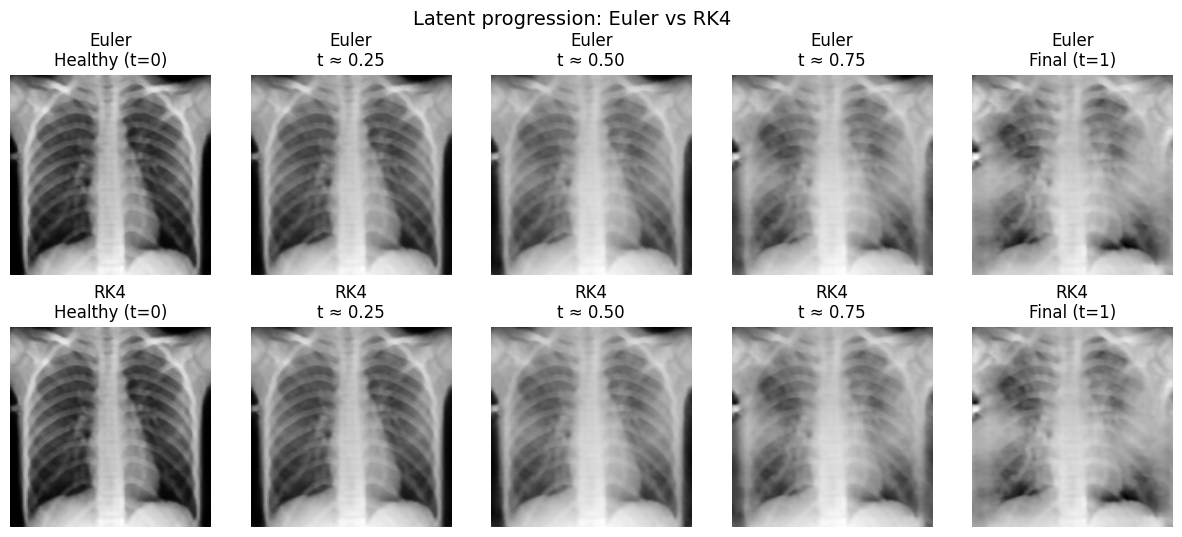

In [15]:
time_indices = [0, 20, 40, 60, 80]

def decode_trajectory(trajectory):

    decoded = []

    with torch.no_grad():
        for t_idx in time_indices:
            z_t = trajectory[:, t_idx].to(device)
            img_t = autoencoder.decode(z_t)
            decoded.append(img_t.cpu())

    return decoded


decoded_euler = decode_trajectory(trajectory_euler)
decoded_rk4   = decode_trajectory(trajectory_rk4)


plt.figure(figsize=(15,6))

# Euler
for i, img in enumerate(decoded_euler):

    plt.subplot(2, len(time_indices), i+1)

    if i == 0:
        title = "Healthy (t=0)"
    elif i == len(time_indices)-1:
        title = "Final (t=1)"
    else:
        title = f"t ≈ {time_indices[i]/80:.2f}"

    plt.title(f"Euler\n{title}")
    plt.imshow(img[0,0], cmap="gray")
    plt.axis("off")


# RK4
for i, img in enumerate(decoded_rk4):

    plt.subplot(2, len(time_indices), len(time_indices) + i + 1)

    if i == 0:
        title = "Healthy (t=0)"
    elif i == len(time_indices)-1:
        title = "Final (t=1)"
    else:
        title = f"t ≈ {time_indices[i]/80:.2f}"

    plt.title(f"RK4\n{title}")
    plt.imshow(img[0,0], cmap="gray")
    plt.axis("off")

plt.suptitle("Latent progression: Euler vs RK4", fontsize=14)
plt.show()

---
Extra amb 5 imatges

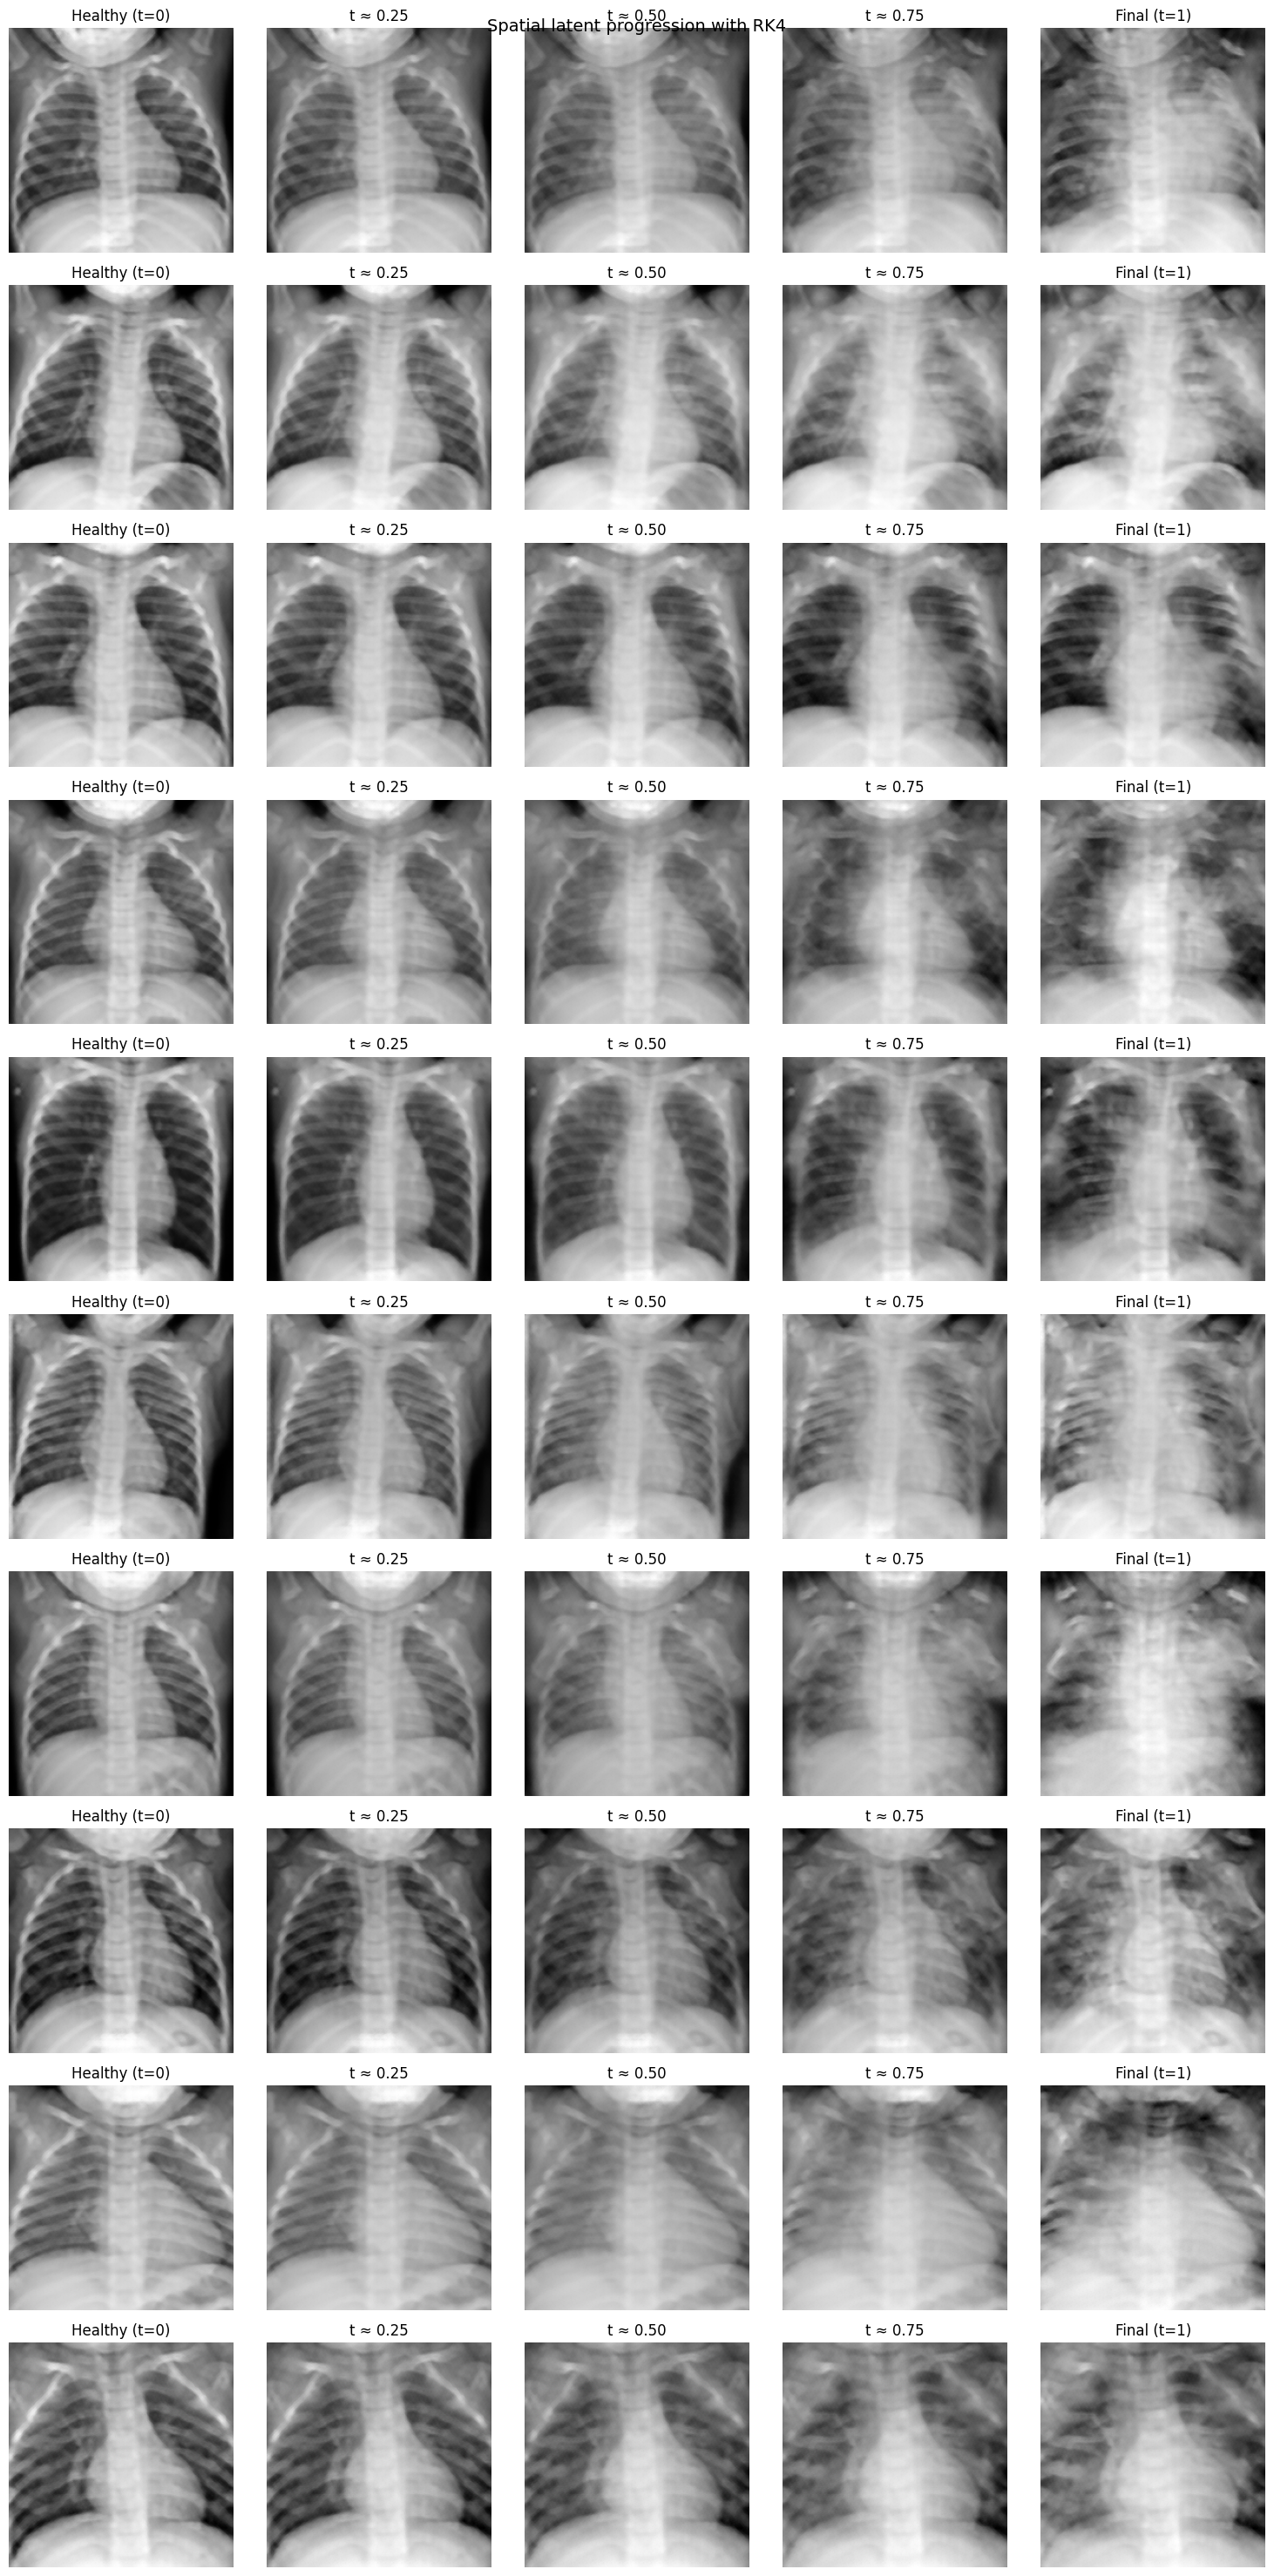

In [16]:
# @title
# Plot 5 spatial trajectories with RK4

vector_field.eval()
autoencoder.eval()

n_examples = 10
n_steps = 80
time_indices = [0, 20, 40, 60, 80]   # must be within [0, n_steps]

# pick 5 healthy real latents
healthy_indices = (labels == 0).nonzero(as_tuple=True)[0]
perm = torch.randperm(healthy_indices.shape[0], device=device)[:n_examples]
chosen_idx = healthy_indices[perm]
z0 = latents[chosen_idx].to(device)         # (5, 4, 28, 28)

# integrate all 5 at once
z_final_rk4, trajectory_rk4 = integrate_rk4(
    vector_field,
    z0,
    n_steps=n_steps
)

# decode selected timesteps
decoded_steps = []
with torch.no_grad():
    for t_idx in time_indices:
        z_t = trajectory_rk4[:, t_idx].to(device)   # (5, 4, 28, 28)
        img_t = autoencoder.decode(z_t)

        decoded_steps.append(img_t.cpu())  # list of (5,1,H,W)

# plot: rows = examples, cols = timesteps
import matplotlib.pyplot as plt

fig, axes = plt.subplots(n_examples, len(time_indices), figsize=(3 * len(time_indices), 3 * n_examples))

for row in range(n_examples):
    for col, t_idx in enumerate(time_indices):
        ax = axes[row, col] if n_examples > 1 else axes[col]
        img = decoded_steps[col][row, 0].numpy()

        if col == 0:
            title = "Healthy (t=0)"
        elif col == len(time_indices) - 1:
            title = "Final (t=1)"
        else:
            title = f"t ≈ {t_idx / n_steps:.2f}"

        ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

        if col == 0:
            ax.set_ylabel(f"Sample {row+1}", fontsize=11)

if MODE == "spatial":
  plt.suptitle("Spatial latent progression with RK4", fontsize=14)
elif MODE == "flat":
  plt.suptitle("Flat latent progression with RK4", fontsize=14)

plt.tight_layout()
plt.show()

Selected healthy dataset index: 3397
RK4 trajectory shape: torch.Size([1, 101, 4, 28, 28])


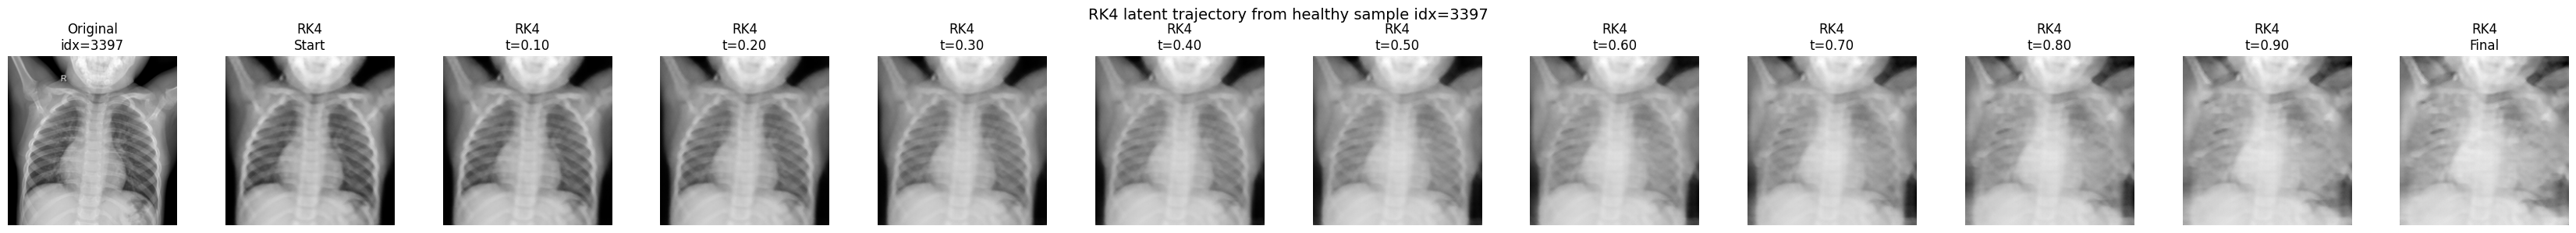

In [17]:
# @title
# One spatial sample with RK4 only

vector_field.eval()
autoencoder.eval()

labels_flat = labels.view(-1)
healthy_indices = (labels_flat == 0).nonzero(as_tuple=True)[0]

# pick one healthy sample
h_local = torch.randint(0, healthy_indices.shape[0], (1,), device=device)
idx_h = healthy_indices[h_local].item()

print(f"Selected healthy dataset index: {idx_h}")

z0 = latents[idx_h].unsqueeze(0).to(device)   # (1,4,28,28)

# integrate with RK4
n_steps = 100
time_indices = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

z_final_rk4, trajectory_rk4 = integrate_rk4(
    vector_field,
    z0,
    n_steps=n_steps
)

print("RK4 trajectory shape:", trajectory_rk4.shape)

# decode trajectory
decoded_rk4 = []
with torch.no_grad():
    for t_idx in time_indices:
        z_t = trajectory_rk4[:, t_idx].to(device)   # (1,4,28,28)
        img_t = autoencoder.decode(z_t)

        decoded_rk4.append(img_t.cpu())

# plot original image + decoded RK4 trajectory
n_cols = len(time_indices) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(2.8 * n_cols, 3))

# original image from dataset
axes[0].imshow(imgs_np[idx_h], cmap="gray")
axes[0].set_title(f"Original\nidx={idx_h}")
axes[0].axis("off")

# decoded intermediate steps
for col, t_idx in enumerate(time_indices, start=1):
    ax = axes[col]
    img = decoded_rk4[col - 1][0, 0].numpy()

    if t_idx == 0:
        title = "RK4\nStart"
    elif t_idx == n_steps:
        title = "RK4\nFinal"
    else:
        title = f"RK4\nt={t_idx/n_steps:.2f}"

    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"RK4 latent trajectory from healthy sample idx={idx_h}", fontsize=14)
plt.tight_layout()
plt.show()